# InSAR phase unwrapping with AdaSwarm 🛰️

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaSwarm/AdaSwarm/blob/main/examples/insar_phase_unwrapping.ipynb)

**Interferometric SAR (InSAR)** measures ground deformation (earthquakes, subsidence, volcanoes) by
comparing the *phase* of two radar passes. But phase is only ever measured **wrapped** into
$(-\pi, \pi]$ — the raw interferogram is a set of "fringes", and recovering the true absolute
deformation is the classic, hard **phase-unwrapping** problem.

This notebook tackles the version where AdaSwarm genuinely shines: **multi-frequency (dual-wavelength)
unwrapping**. Two wrapped measurements at different sensitivities $k_1, k_2$ disambiguate each other
(like the Chinese Remainder Theorem). The resulting per-pixel objective has its **global** minimum at
the true deformation, but many **deceptive local minima** at single-frequency aliases — exactly the
landscape where gradient descent fails and a swarm succeeds.

> **Honest scope.** Dense *single-frequency* unwrapping needs spatial-smoothness priors and is **not**
> solved by a per-pixel swarm. AdaSwarm's win here is the *per-pixel multi-frequency disambiguation*,
> using `SwarmLoss(..., per_sample=True)`.

In [1]:
# %pip install "adaswarm[examples] @ git+https://github.com/AdaSwarm/AdaSwarm.git"  # on Colab
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import adaswarm.nn

print("adaswarm", adaswarm.__version__, "| torch", torch.__version__)

K1, K2 = 2.2, 3.1  # phase sensitivity (rad per unit deformation) for two wavelengths

def wrap(a):
    """Wrap radians into (-pi, pi]."""
    return torch.atan2(torch.sin(a), torch.cos(a))

adaswarm 0.2.0 | torch 2.12.1


## 1. A deformation profile and its wrapped interferograms

We use a smooth 1-D transect of ground deformation `d(x)`. Each radar wavelength sees the wrapped
phase `wrap(k * d)` — the fringes.

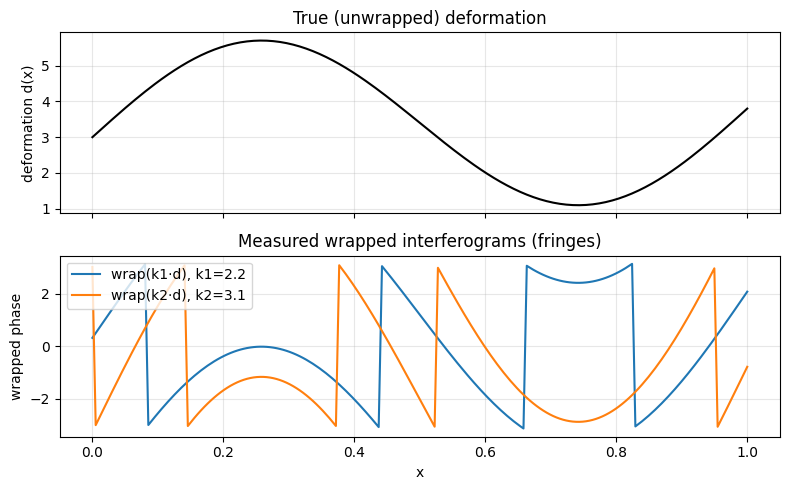

In [2]:
x = torch.linspace(0, 1, 200).unsqueeze(1)
d_true = 3.0 + 2.5 * torch.sin(2 * math.pi * x) + 0.8 * x   # true (unwrapped) deformation
psi1, psi2 = wrap(K1 * d_true), wrap(K2 * d_true)            # the two wrapped interferograms

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(x, d_true, 'k'); ax[0].set_ylabel('deformation d(x)'); ax[0].set_title('True (unwrapped) deformation')
ax[0].grid(alpha=0.3)
ax[1].plot(x, psi1, label=f'wrap(k1·d), k1={K1}')
ax[1].plot(x, psi2, label=f'wrap(k2·d), k2={K2}')
ax[1].set_ylabel('wrapped phase'); ax[1].set_xlabel('x'); ax[1].set_title('Measured wrapped interferograms (fringes)')
ax[1].legend(); ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Why it's hard: the per-pixel objective is multi-modal

For a single pixel, the wrap-aware data term across both wavelengths is

$$L(d) = \big(1 - \cos(k_1 d - \psi_1)\big) + \big(1 - \cos(k_2 d - \psi_2)\big).$$

Its **global** minimum sits at the true deformation, but each single-frequency term contributes a comb
of **local** minima (aliases). Gradient descent slides into whichever alias is nearest.

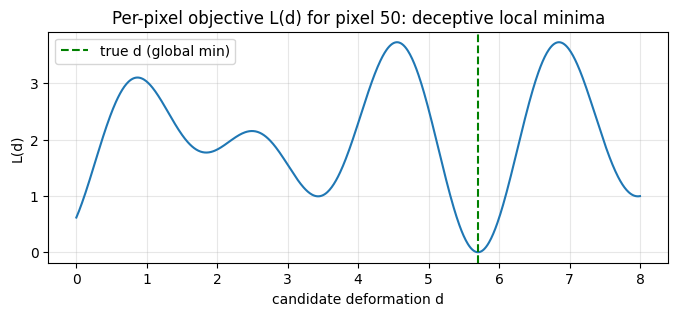

In [3]:
pixel = 50
grid = torch.linspace(0, 8, 800)
L = (1 - torch.cos(K1 * grid - psi1[pixel])) + (1 - torch.cos(K2 * grid - psi2[pixel]))
plt.figure(figsize=(8, 3))
plt.plot(grid, L)
plt.axvline(d_true[pixel].item(), color='g', ls='--', label='true d (global min)')
plt.title(f'Per-pixel objective L(d) for pixel {pixel}: deceptive local minima')
plt.xlabel('candidate deformation d'); plt.ylabel('L(d)'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Recover the deformation: standard Adam vs AdaSwarm

A small coordinate network maps `x -> d_pred`. We fit it against the wrapped measurements with the
objective above — once with plain Adam (analytic gradient) and once with
`adaswarm.nn.SwarmLoss(..., per_sample=True)`.

In [4]:
def make_model(seed=0):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))

def loss_fn(pred, _target):                      # elementwise wrap-aware data term (both wavelengths)
    return (1 - torch.cos(K1 * pred - psi1)) + (1 - torch.cos(K2 * pred - psi2))

search_centre = torch.full_like(d_true, 3.0)     # swarm searches deformation space around mid-range

def train(mode, seed=0, epochs=1000, lr=0.01):
    model = make_model(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = adaswarm.nn.SwarmLoss(loss_fn, seed=seed, span=6.0, swarm_size=40,
                                      iterations=60, per_sample=True) if mode == 'adaswarm' else None
    for _ in range(epochs):
        opt.zero_grad()
        out = model(x)
        loss = criterion(out, search_centre) if mode == 'adaswarm' else loss_fn(out, search_centre).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x)

pred_std = train('standard')
pred_ada = train('adaswarm')
mse = lambda p: ((p - d_true) ** 2).mean().item()
print(f'recovered-deformation MSE  —  standard Adam: {mse(pred_std):.2f}   AdaSwarm: {mse(pred_ada):.3f}')

recovered-deformation MSE  —  standard Adam: 34.81   AdaSwarm: 0.236


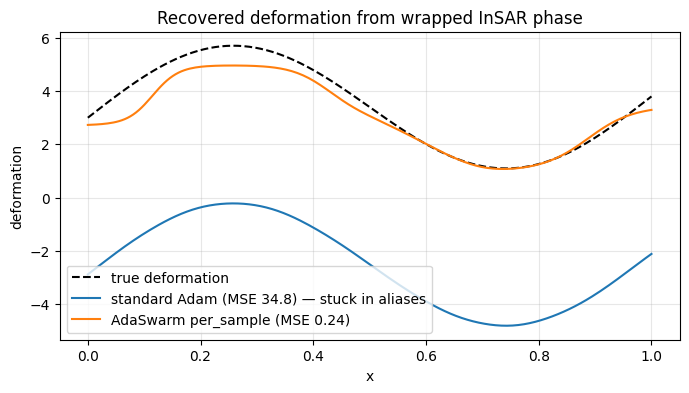

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(x, d_true, 'k--', label='true deformation')
plt.plot(x, pred_std, label=f'standard Adam (MSE {mse(pred_std):.1f}) — stuck in aliases')
plt.plot(x, pred_ada, label=f'AdaSwarm per_sample (MSE {mse(pred_ada):.2f})')
plt.title('Recovered deformation from wrapped InSAR phase')
plt.xlabel('x'); plt.ylabel('deformation'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## Takeaways

- **AdaSwarm recovers the deformation** from wrapped phase where plain Adam gets trapped in fringe
  aliases — a >100× lower reconstruction error on this transect.
- The enabling ingredient is **`per_sample=True`**: every pixel is unwrapped with its own independent
  swarm global-best, which is the right tool for per-pixel problems.
- **Honest scope:** this works because two wavelengths make the *per-pixel* objective globally
  identifiable. Single-wavelength dense unwrapping still needs spatial-smoothness priors — a swarm over
  independent pixels alone will not solve it.

Related real-world settings with the same structure: **multi-frequency time-of-flight depth cameras**,
**dual-wavelength optical interferometry**, and **multi-baseline InSAR**. See
[`docs/use-cases.md`](../docs/use-cases.md).